In [1]:
from dataclasses import dataclass
from typing import Dict, List

import lightning.pytorch as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df_all_country = pd.read_csv("C:\\Users\\ADMIN\\Downloads\\MODEL_TFT\\data\\all_electric_data_16_country.csv")
df_all_country.head(100)

,entity,date,series,generation_TWh,precipitation,solar,humidity,temperature
0,Argentina,01/01/2018,Bioenergy,0.02,10648.72,24.537102,9.435314,18.193195
1,Argentina,01/01/2018,Coal,0.26,10648.72,24.537102,9.435314,18.193195
2,Argentina,01/01/2018,Gas,7.79,10648.72,24.537102,9.435314,18.193195
3,Argentina,01/01/2018,Hydro,3.69,10648.72,24.537102,9.435314,18.193195
4,Argentina,01/01/2018,Nuclear,0.64,10648.72,24.537102,9.435314,18.193195
...,...,...,...,...,...,...,...,...
95,Argentina,01/11/2018,Other Fossil,0.11,11315.31,23.561341,8.295639,15.132975
96,Argentina,01/11/2018,Solar,0.02,11315.31,23.561341,8.295639,15.132975
97,Argentina,01/11/2018,Wind,0.22,11315.31,23.561341,8.295639,15.132975
98,Argentina,01/11/2018,Total Generation,10.38,11315.31,23.561341,8.295639,15.132975


In [3]:
df_all_country.tail()

,entity,date,series,generation_TWh,precipitation,solar,humidity,temperature
11012,Viet Nam,2024-12-01,Hydro,11.29,143.5,338.78,77.580645,22.303226
11013,Viet Nam,2024-12-01,Other fossil,0.00,143.5,338.78,77.580645,22.303226
11014,Viet Nam,2024-12-01,Solar,2.27,143.5,338.78,77.580645,22.303226
11015,Viet Nam,2024-12-01,Total generation,26.91,143.5,338.78,77.580645,22.303226
11016,Viet Nam,2024-12-01,Wind,0.90,143.5,338.78,77.580645,22.303226


In [4]:
df_all_country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   entity          11017 non-null  object 
 1   date            11017 non-null  object 
 2   series          11017 non-null  object 
 3   generation_TWh  11017 non-null  float64
 4   precipitation   11017 non-null  float64
 5   solar           11017 non-null  float64
 6   humidity        11017 non-null  float64
 7   temperature     11017 non-null  float64
dtypes: float64(5), object(3)
memory usage: 688.7+ KB


In [5]:
# =============================================================================
# CELL 1 — TIỀN XỬ LÝ DỮ LIỆU
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

df = df_all_country.copy()

# ── 3.1 Chuẩn hoá tên series (Viet Nam dùng chữ thường, các nước khác dùng hoa) ──
series_map = {
    "Total generation": "Total Generation",
    "Other fossil":     "Other Fossil",
}
df["series"] = df["series"].replace(series_map)

# ── 3.2 Chuyển đổi date → datetime ────────────────────────────────────────────
# Argentina và các nước: "DD/MM/YYYY" | Viet Nam: "YYYY-MM-DD"
df["date"] = pd.to_datetime(df["date"], format="mixed", dayfirst=True)

# ── 3.3 Sắp xếp theo entity, series, date ────────────────────────────────────
df = df.sort_values(["entity", "series", "date"]).reset_index(drop=True)

# ── 3.4 Tạo group_id = entity + ' | ' + series ───────────────────────────────
df["group_id"] = df["entity"] + " | " + df["series"]

# ── 3.5 Tạo time_idx toàn bộ theo số tháng kể từ điểm đầu ─────────────────
min_date = df["date"].min()
df["time_idx"] = (
    (df["date"].dt.year  - min_date.year) * 12
    + (df["date"].dt.month - min_date.month)
).astype(int)

# ── 3.6 Trích xuất biến month (categorical) ──────────────────────────────────
df["month"] = df["date"].dt.month.astype(str)   # '1' … '12'

# ── 3.7 Tạo sample_weight — Viet Nam gấp 3 lần các nước khác ────────────────
df["sample_weight"] = np.where(df["entity"] == "Viet Nam", 3.0, 1.0)

# ── 3.8 Kiểm tra nhanh ────────────────────────────────────────────────────────
print("Shape          :", df.shape)
print("Date range     :", df["date"].min().date(), "→", df["date"].max().date())
print("Entities       :", sorted(df["entity"].unique()))
print("Series         :", sorted(df["series"].unique()))
print("Total group_id :", df["group_id"].nunique())
print("\nSample weight per entity:")
print(df.groupby("entity")["sample_weight"].first().to_string())
df.head()

Shape          : (11017, 12)
Date range     : 2018-01-01 → 2025-12-01
Entities       : ['Argentina', 'Bangladesh', 'Brazil', 'Colombia', 'Egypt', 'India', 'Malaysia', 'Mexico', 'Pakistan', 'Peru', 'Philippines', 'South Africa', 'Thailand', 'Turkey', 'Viet Nam']
Series         : ['Bioenergy', 'Coal', 'Gas', 'Hydro', 'Nuclear', 'Other Fossil', 'Other Renewables', 'Solar', 'Total Generation', 'Wind']
Total group_id : 126

Sample weight per entity:
entity
Argentina       1.0
Bangladesh      1.0
Brazil          1.0
Colombia        1.0
Egypt           1.0
India           1.0
Malaysia        1.0
Mexico          1.0
Pakistan        1.0
Peru            1.0
Philippines     1.0
South Africa    1.0
Thailand        1.0
Turkey          1.0
Viet Nam        3.0


,entity,date,series,generation_TWh,precipitation,solar,humidity,temperature,group_id,time_idx,month,sample_weight
0,Argentina,2018-01-01,Bioenergy,0.02,10648.72,24.537102,9.435314,18.193195,Argentina | Bioenergy,0,1,1.0
1,Argentina,2018-02-01,Bioenergy,0.02,6886.61,22.315455,9.437452,18.337836,Argentina | Bioenergy,1,2,1.0
2,Argentina,2018-03-01,Bioenergy,0.02,8798.65,18.051761,8.606008,16.500330,Argentina | Bioenergy,2,3,1.0
3,Argentina,2018-04-01,Bioenergy,0.02,8490.94,12.733422,8.454025,15.133189,Argentina | Bioenergy,3,4,1.0
4,Argentina,2018-05-01,Bioenergy,0.03,8964.45,8.799104,7.130631,11.819865,Argentina | Bioenergy,4,5,1.0


In [6]:
# =============================================================================
# CELL 4 — CHIA TRAIN / VALIDATION (Kiểm tra Data Leakage - Time-based Split)
# =============================================================================
MAX_ENCODER_LENGTH    = 24   # Nhìn lại 24 tháng (2 năm)
MAX_PREDICTION_LENGTH = 12   # Dự báo 12 tháng kế tiếp

# ── 4.1 Kiểm tra phạm vi date ──────────────────────────────────────────────
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())
print("time_idx range:", df["time_idx"].min(), "→", df["time_idx"].max())

# ── 4.2 Time-based split: Validation là 12 tháng CUỐI ─────────────────────
# KHÔNG dùng shuffle trên tập train (TimeSeriesDataSet tự xử lý)
training_cutoff = df["time_idx"].max() - MAX_PREDICTION_LENGTH
val_cutoff      = df["time_idx"].max()

df_train = df[df["time_idx"] <= training_cutoff].copy()
df_val   = df.copy()   # Toàn bộ data để validate (pytorch_forecasting predict=True sẽ lấy phần đúng)

print(f"\nTraining cutoff time_idx: {training_cutoff} (date ≈ {df[df['time_idx']==training_cutoff]['date'].max().date()})")
print(f"Train rows               : {len(df_train):,}")
print(f"Val rows (full df)       : {len(df_val):,}")
print(f"\n[OK] Validation data nằm SAU training data về mặt thời gian.")


Date range: 2018-01-01 → 2025-12-01
time_idx range: 0 → 95

Training cutoff time_idx: 83 (date ≈ 2024-12-01)
Train rows               : 9,877
Val rows (full df)       : 11,017

[OK] Validation data nằm SAU training data về mặt thời gian.


In [7]:
# =============================================================================
# CELL 5 — TẠO TimeSeriesDataSet (Không Data Leakage)
# =============================================================================
# Giải thích thiết kế:
# - time_varying_known_reals  : Biến BIẾT TRƯỚC tại thời điểm dự báo (thời tiết, v.v.)
#   → Trong bài toán này, thời tiết thường được coi là UNKNOWN vì không biết trước
#   → Ta để thời tiết vào UNKNOWN để mô hình không "nhìn thấy" tương lai
# - time_varying_unknown_reals: generation_TWh (target) + thời tiết (không biết trước)
#   → TFT chỉ dùng encoder window cho unknown_reals, KHÔNG leak
# - generation_TWh tự động được TFT dùng làm input encoder (autoregressive) → đúng thiết kế

STATIC_CATEGORICALS = ["entity", "series"]
TIME_KNOWN_CAT      = ["month"]

# Thời tiết → unknown (không biết giá trị tương lai)
# generation_TWh là target, TFT tự động handle encoder/decoder split
TIME_UNKNOWN_REALS  = ["generation_TWh",
                        "precipitation", "solar", "humidity", "temperature"]

# ── Training dataset ─────────────────────────────────────────────────────────
training = TimeSeriesDataSet(
    df_train,
    time_idx                        = "time_idx",
    target                          = "generation_TWh",
    group_ids                       = ["group_id"],
    min_encoder_length              = MAX_ENCODER_LENGTH // 2,
    max_encoder_length              = MAX_ENCODER_LENGTH,
    min_prediction_length           = 1,
    max_prediction_length           = MAX_PREDICTION_LENGTH,
    static_categoricals             = STATIC_CATEGORICALS,
    time_varying_known_categoricals = TIME_KNOWN_CAT,
    time_varying_unknown_reals      = TIME_UNKNOWN_REALS,
    target_normalizer               = GroupNormalizer(
        groups=["group_id"],
        transformation="softplus",
    ),
    add_relative_time_idx  = True,
    add_target_scales      = True,
    add_encoder_length     = True,
    weight                 = "sample_weight",
    allow_missing_timesteps= True,
)

# ── Validation dataset ────────────────────────────────────────────────────────
validation = TimeSeriesDataSet.from_dataset(
    training,
    df_val,
    predict=True,
    stop_randomization=True,
)

print("Training dataset :")
print(f"  Số mẫu (sau sliding window): {len(training)}")
print(f"  Số nhóm (group_id)          : {df_train['group_id'].nunique()}")
print("\nValidation dataset :")
print(f"  Số mẫu                      : {len(validation)}")
print("\n[OK] Dataset được tạo không có data leakage.")


Training dataset :
  Số mẫu (sau sliding window): 11263
  Số nhóm (group_id)          : 126

Validation dataset :
  Số mẫu                      : 126

[OK] Dataset được tạo không có data leakage.


In [8]:
# =============================================================================
# CELL 6 — TẠO DataLoader
# =============================================================================
BATCH_SIZE  = 64
NUM_WORKERS = 0   # Windows: để 0 tránh lỗi multiprocessing

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE * 2,
    num_workers=NUM_WORKERS,
    shuffle=False,
)

# Kiểm tra một batch
batch_x, batch_y = next(iter(train_dataloader))
print("encoder_cont shape :", batch_x["encoder_cont"].shape)
print("decoder_cont shape :", batch_x["decoder_cont"].shape)
print("target shape       :", batch_y[0].shape)



encoder_cont shape : torch.Size([64, 24, 9])
decoder_cont shape : torch.Size([64, 12, 9])
target shape       : torch.Size([64, 12])


In [9]:
# =============================================================================
# CELL 7 — ĐỊNH NGHĨA MÔ HÌNH TFT
# =============================================================================
tft = TemporalFusionTransformer.from_dataset(
    training,
    # Kiến trúc
    learning_rate           = 3e-3,
    hidden_size             = 64,
    attention_head_size     = 4,
    dropout                 = 0.1,
    hidden_continuous_size  = 32,
    # Loss
    loss                    = QuantileLoss(quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
    output_size             = 5,   # Phải bằng số quantile
    # Logging
    log_interval            = 20,
    reduce_on_plateau_patience = 5,
)

print(f"Số tham số mô hình: {tft.size() / 1e3:.1f}K")
print(tft)


Số tham số mô hình: 278.4K
TemporalFusionTransformer(
  	"attention_head_size":               4
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'generation_TWh', 'group_ids': ['group_id'], 'weight': 'sample_weight', 'max_encoder_length': 24, 'min_encoder_length': 12, 'min_prediction_idx': np.int64(0), 'min_prediction_length': 1, 'max_prediction_length': 12, 'static_categoricals': ['entity', 'series'], 'static_reals': None, 'time_varying_known_categoricals': ['month'], 'time_varying_known_reals': None, 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['generation_TWh', 'precipitation', 'solar', 'humidity', 'temperature'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': True, 'lags': None, 'add_relative_time_idx': True, 'add_target_scales': True, 'add_encoder_length': True, 'target_normalizer': GroupNormalizer(
  		

In [10]:
# =============================================================================
# CELL 8 — HUẤN LUYỆN MÔ HÌNH
# =============================================================================
import os

CHECKPOINT_DIR = r"C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Callbacks
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=10,
    verbose=True,
    mode="min",
)

lr_logger = LearningRateMonitor()

checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename="tft-{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,
    monitor="val_loss",
    mode="min",
)

# Trainer
trainer = pl.Trainer(
    max_epochs          = 100,
    accelerator         = "gpu" if torch.cuda.is_available() else "cpu",
    devices             = 1,
    gradient_clip_val   = 0.1,
    callbacks           = [early_stop_callback, lr_logger, checkpoint_callback],
    enable_progress_bar = True,
    log_every_n_steps   = 10,
)

print(f"Huấn luyện trên: {'GPU' if torch.cuda.is_available() else 'CPU'}")

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Huấn luyện trên: CPU


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    237 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    576 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 21.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 42.6 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  7.1 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    325 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 278 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 278 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 329                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.382


Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.378


Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.374


Metric val_loss improved by 0.002 >= min_delta = 0.0. New best score: 0.372


Monitored metric val_loss did not improve in the last 10 records. Best score: 0.372. Signaling Trainer to stop.


Loading best model from: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\tft\tft-epoch=25-val_loss=0.3715.ckpt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Mô hình trả về Point Forecast (2D Tensor)

   MAE            : 0.4416  TWh
   RMSE           : 1.1082  TWh
   MAPE (safe)    : 20.59  %  (loại 182 điểm < 0.05 TWh)
   R²             : 0.9961

── Phân tích MAPE theo dải giá trị generation_TWh ──
  [     <0.05 TWh]  n= 182  MAPE=806372.25%
  [  0.05-0.5 TWh]  n= 319  MAPE=  42.53%
  [     0.5-2 TWh]  n= 361  MAPE=  19.86%
  [       2-5 TWh]  n= 242  MAPE=  15.73%
  [      5-10 TWh]  n= 149  MAPE=  10.29%
  [     10-20 TWh]  n= 160  MAPE=   6.05%
  [       >20 TWh]  n=  99  MAPE=   3.46%


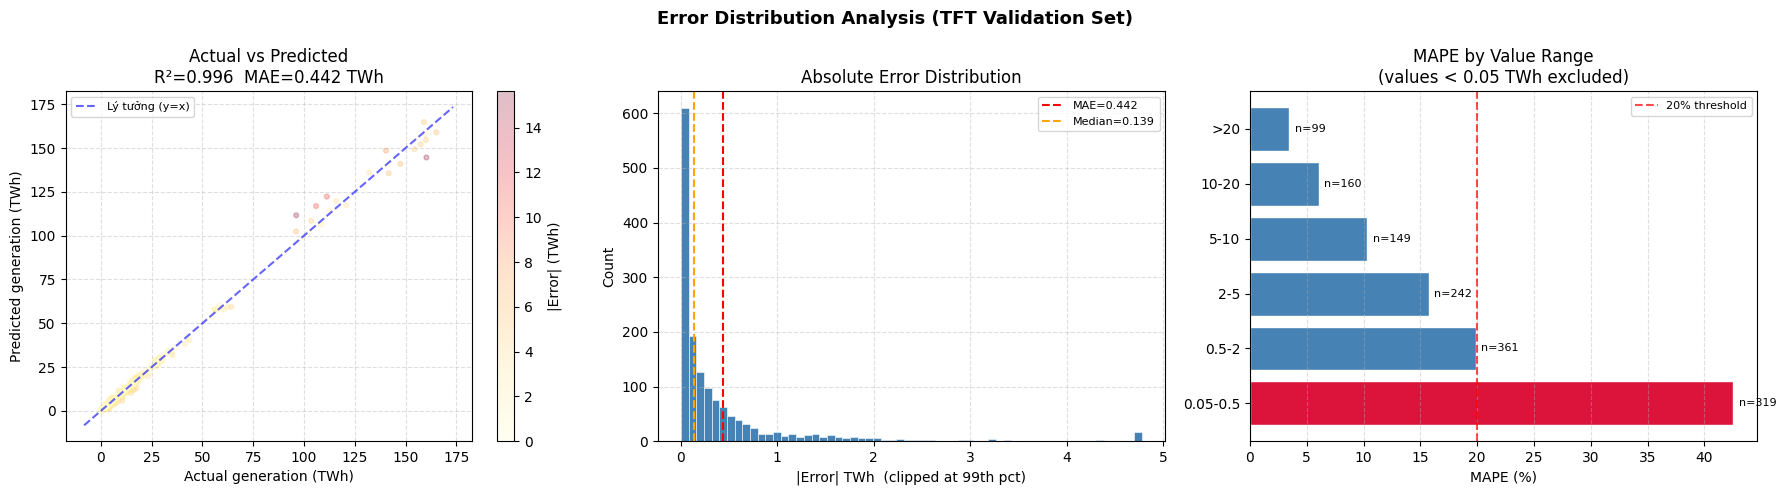


[OK] Phân tích hoàn tất. Các series có MAPE cao (màu đỏ) thường là năng lượng tái tạo nhỏ.


In [13]:
# =============================================================================
# CELL 9 — ĐÁNH GIÁ CHI TIẾT (MAE, RMSE, MAPE theo series + Error Distribution)
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── 1. Load best checkpoint ──────────────────────────────────────────────────
best_model_path = checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path}")

best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
best_tft.eval()

# ── 2. Dự báo trên tập validation ───────────────────────────────────────────
predictions = best_tft.predict(
    val_dataloader,
    return_y=True,
    trainer_kwargs=dict(accelerator="gpu" if torch.cuda.is_available() else "cpu"),
)

# ── 3. Trích xuất Output dự báo ───────────────────────────────────────────────
raw_output = predictions.output if hasattr(predictions, "output") else predictions[0]

if raw_output.ndim == 3:
    median_idx = raw_output.shape[2] // 2
    y_pred = raw_output[:, :, median_idx].detach().cpu().numpy().flatten()
    print(f"Đã trích xuất Median từ Quantile index: {median_idx}")
else:
    y_pred = raw_output.detach().cpu().numpy().flatten()
    print("Mô hình trả về Point Forecast (2D Tensor)")

# ── 4. Trích xuất Ground Truth ────────────────────────────────────────────────
raw_y = predictions.y if hasattr(predictions, "y") else predictions[1]

if isinstance(raw_y, (tuple, list)):
    y_true = raw_y[0].detach().cpu().numpy().flatten()
else:
    y_true = raw_y.detach().cpu().numpy().flatten()

# Đảm bảo khớp kích thước
min_len = min(len(y_true), len(y_pred))
y_true, y_pred = y_true[:min_len], y_pred[:min_len]

# ── 5. Tính toán Metrics tổng thể ────────────────────────────────────────────
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

# MAPE an toàn: loại bỏ các điểm y_true < 0.05 TWh (tránh chia gần 0)
MAPE_THRESHOLD = 0.05   # 0.05 TWh ~ giá trị nhỏ nhất có nghĩa
mask_mape = y_true >= MAPE_THRESHOLD
mape_safe = np.mean(np.abs((y_true[mask_mape] - y_pred[mask_mape]) / y_true[mask_mape])) * 100
n_excluded = np.sum(~mask_mape)

print(f"\n{'='*55}")
print(f"   MAE            : {mae:.4f}  TWh")
print(f"   RMSE           : {rmse:.4f}  TWh")
print(f"   MAPE (safe)    : {mape_safe:.2f}  %  (loại {n_excluded} điểm < {MAPE_THRESHOLD} TWh)")
print(f"   R²             : {r2:.4f}")
print(f"{'='*55}")

# ── 6. Phân tích MAPE theo dải giá trị ──────────────────────────────────────
print("\n── Phân tích MAPE theo dải giá trị generation_TWh ──")
bins = [0, 0.05, 0.5, 2, 5, 10, 20, np.inf]
labels = ["<0.05", "0.05-0.5", "0.5-2", "2-5", "5-10", "10-20", ">20"]

for lo, hi, lbl in zip(bins[:-1], bins[1:], labels):
    mask_bin = (y_true >= lo) & (y_true < hi)
    if mask_bin.sum() > 0:
        mape_bin = np.mean(np.abs((y_true[mask_bin] - y_pred[mask_bin]) / np.maximum(y_true[mask_bin], 1e-6))) * 100
        print(f"  [{lbl:>10} TWh]  n={mask_bin.sum():4d}  MAPE={mape_bin:7.2f}%")

# ── 7. Error Distribution Plot ───────────────────────────────────────────────
errors = y_pred - y_true
pct_errors = (errors / np.maximum(np.abs(y_true), MAPE_THRESHOLD)) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Error Distribution Analysis (TFT Validation Set)", fontsize=13, fontweight="bold")

# (a) Scatter: True vs Pred
ax = axes[0]
sc = ax.scatter(y_true, y_pred, alpha=0.25, s=12, c=np.abs(errors), cmap="YlOrRd")
plt.colorbar(sc, ax=ax, label="|Error| (TWh)")
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "b--", alpha=0.6, label="Lý tưởng (y=x)")
ax.set_xlabel("Actual generation (TWh)")
ax.set_ylabel("Predicted generation (TWh)")
ax.set_title(f"Actual vs Predicted\nR²={r2:.3f}  MAE={mae:.3f} TWh")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.4)

# (b) Histogram của absolute errors
ax = axes[1]
clip_err = np.clip(np.abs(errors), 0, np.percentile(np.abs(errors), 99))
ax.hist(clip_err, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(mae, color="red", linestyle="--", label=f"MAE={mae:.3f}")
ax.axvline(np.median(np.abs(errors)), color="orange", linestyle="--",
           label=f"Median={np.median(np.abs(errors)):.3f}")
ax.set_xlabel("|Error| TWh  (clipped at 99th pct)")
ax.set_ylabel("Count")
ax.set_title("Absolute Error Distribution")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.4)

# (c) MAPE phân theo dải giá trị
ax = axes[2]
bin_mapes, bin_counts, bin_labels2 = [], [], []
for lo, hi, lbl in zip(bins[:-1], bins[1:], labels):
    mask_bin = (y_true >= lo) & (y_true < hi) & (y_true >= MAPE_THRESHOLD)
    if mask_bin.sum() > 0:
        mape_bin = np.mean(np.abs((y_true[mask_bin] - y_pred[mask_bin]) / y_true[mask_bin])) * 100
        bin_mapes.append(mape_bin)
        bin_counts.append(mask_bin.sum())
        bin_labels2.append(lbl)

colors = ["crimson" if m > 20 else "steelblue" for m in bin_mapes]
bars = ax.barh(bin_labels2, bin_mapes, color=colors, edgecolor="white")
ax.axvline(20, color="red", linestyle="--", alpha=0.7, label="20% threshold")
for bar, cnt in zip(bars, bin_counts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"n={cnt}", va="center", fontsize=8)
ax.set_xlabel("MAPE (%)")
ax.set_title("MAPE by Value Range\n(values < 0.05 TWh excluded)")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.4, axis="x")

plt.tight_layout()
plt.show()
print("\n[OK] Phân tích hoàn tất. Các series có MAPE cao (màu đỏ) thường là năng lượng tái tạo nhỏ.")


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


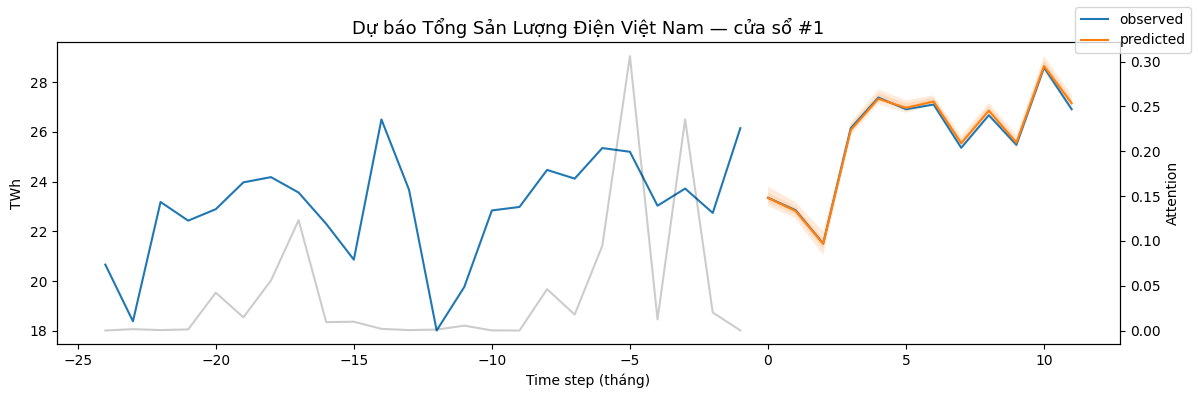

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


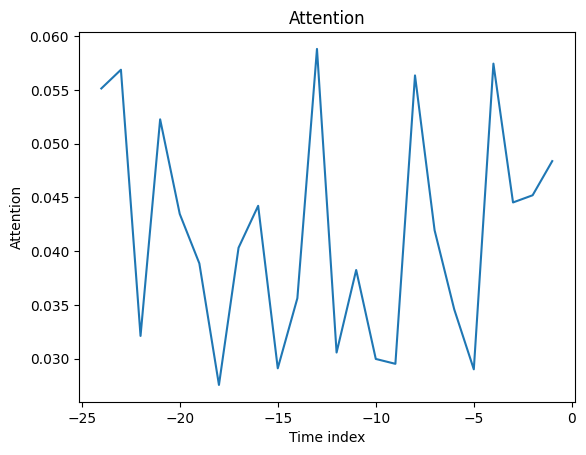

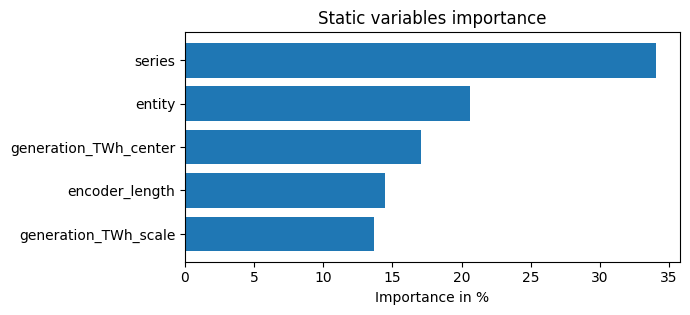

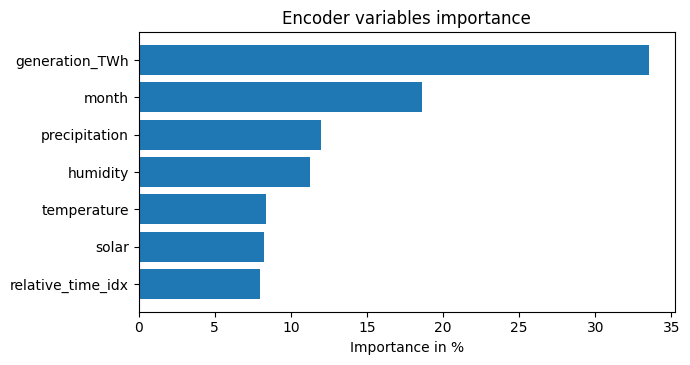

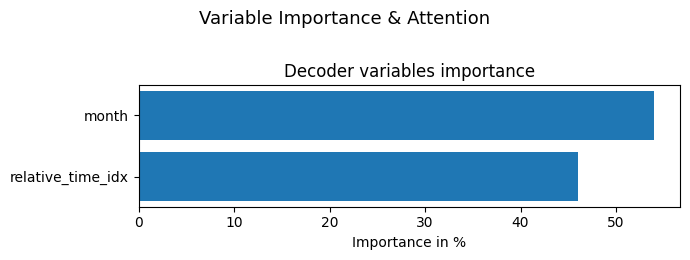

In [14]:
# =============================================================================
# CELL 10 — VẼ BIỂU ĐỒ DỰ BÁO VIỆT NAM & VARIABLE IMPORTANCE
# =============================================================================

# ── 10-a: Tạo dataloader riêng cho Viet Nam | Total Generation ───────────────
VN_GROUP = "Viet Nam | Total Generation"

vn_df = df_val[df_val["group_id"] == VN_GROUP].copy()

vn_dataset = TimeSeriesDataSet.from_dataset(
    training,
    vn_df,
    predict=True,
    stop_randomization=True,
)
vn_dataloader = vn_dataset.to_dataloader(
    train=False,
    batch_size=64,
    num_workers=0,
    shuffle=False,
)

# ── 10-b: Lấy raw predictions (cần x + output để plot) ──────────────────────
raw_preds_vn = best_tft.predict(
    vn_dataloader,
    mode="raw",
    return_x=True,
)

# ── 10-c: Vẽ biểu đồ dự báo (idx = 0 → cửa sổ cuối cùng) ──────────────────
n_plots = min(3, len(raw_preds_vn.output.prediction))  # vẽ tối đa 3 cửa sổ

for idx in range(n_plots):
    fig, ax = plt.subplots(figsize=(12, 4))
    best_tft.plot_prediction(
        raw_preds_vn.x,
        raw_preds_vn.output,
        idx=idx,
        ax=ax,
        show_future_observed=True,
    )
    ax.set_title(f"Dự báo Tổng Sản Lượng Điện Việt Nam — cửa sổ #{idx+1}", fontsize=13)
    ax.set_ylabel("TWh")
    ax.set_xlabel("Time step (tháng)")
    plt.tight_layout()
    plt.show()

# ── 10-d: Variable Importance cho toàn bộ validation set ────────────────────
raw_preds_all = best_tft.predict(
    val_dataloader,
    mode="raw",
    return_x=True,
)

interpretation = best_tft.interpret_output(
    raw_preds_all.output,
    reduction="sum",
)

best_tft.plot_interpretation(interpretation)
plt.suptitle("Variable Importance & Attention", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
